In [1]:
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
import lightgbm as lgb

import os
import sys
root_path="/home/iaw/DATA2/AAReact/src"
sys.path.append(root_path)
from util.RegressMetrics import r2_score, mse_score, mae_score, rmse_score
from util.train_tools import build_model, search_parms, print_metric, draw_pred_result

import seaborn as sns
from matplotlib import pyplot as plt

from typing import List, Tuple
from rich.table import Table
from rich import print as rp
from rich.progress import track

import pickle

In [2]:

seed = 1
test_size = 0.2
prefix = "/home/iaw/DATA2/AAReact/DataSet/AtropicAcid_416/4_gen_feature/rdkit_3"
data_x = np.load("{}_data_x.npy".format(prefix))
data_y = np.load("{}_data_y.npy".format(prefix))
with open("{}_x_label.pkl".format(prefix), "rb") as f:
    x_label = pickle.load(f)
with open("{}_data_class.pkl".format(prefix), "rb") as f:
    data_class = pickle.load(f)
# 超参之后的参数
xgb_best_params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 150, 'subsample': 0.8}
rf_best_params = {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 140}

X_train, X_test, y_train, y_test,  class_train, class_test = train_test_split(
    data_x,        
    data_y,
    data_class,
    test_size=test_size,
    random_state=seed, 
)

# 加入一部分新的数据点

In [3]:
# 加载新的数据
new_cat_71_data_x = [np.load(i) for i in [  "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_71_rea1_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_71_rea2_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_71_rea3_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_71_rea4_20.npy"]]
new_cat_72_data_x = [np.load(i) for i in [  "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_72_rea1_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_72_rea2_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_72_rea3_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_72_rea4_20.npy"]]
new_cat_73_data_x = [np.load(i) for i in [  "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_73_rea1_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_73_rea2_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_73_rea3_20.npy"
                        , "/home/iaw/DATA2/AAReact/test/iter_1/iter1_pred_new_cat/cat_73_rea4_20.npy"]]

# list -> NDArray
new_cat_71_data_x = np.array(new_cat_71_data_x)
new_cat_72_data_x = np.array(new_cat_72_data_x)
new_cat_73_data_x = np.array(new_cat_73_data_x)

# 只取第一个底物加入
new_cat_71_data_x_rea1 = new_cat_71_data_x[0, :]
new_cat_72_data_x_rea1 = new_cat_72_data_x[0, :]
new_cat_73_data_x_rea1 = new_cat_73_data_x[0, :]

X_train_new = np.vstack([X_train, new_cat_71_data_x_rea1,new_cat_72_data_x_rea1,new_cat_73_data_x_rea1])
y_train_new = np.concatenate([y_train, np.array([0.80,-0.33,0.346])])
class_train.extend([4, 4, 4])


In [4]:
# new test
X_test_new = np.vstack([X_test, new_cat_71_data_x[1:, :],new_cat_72_data_x[1:, :],new_cat_73_data_x[1:, :]])
y_test_new = np.concatenate([y_test, np.array([0.0678, 0.223, 0.380 ,-0.6241, -0.327, -0.137 ,0.483, 0.638, 0.396])])
class_test.extend([4, 4, 4, 4, 4, 4, 4, 4, 4])

In [5]:
model = build_model("xgb", seed)
model.set_params(**xgb_best_params)
model.fit(X_train_new, y_train_new)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
#model = build_model("rf", seed)
#model.set_params(**rf_best_params)
#model.fit(X_train_new, y_train_new)

,n_estimators,140
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
train_pred = model.predict(X_train_new)
test_pred = model.predict(X_test_new)
r2_train = r2_score(train_pred, y_train_new)
r2_test = r2_score(test_pred, y_test_new)

In [8]:
test_pred[-9:]

array([ 0.34757584,  0.21831873,  0.26009887, -0.25273448,  0.11029462,
        0.04988674, -0.07884711,  0.28971514,  0.17465992], dtype=float32)

In [9]:
class_train_new = [0 for i in range(332)] + [1, 1, 1]
class_test_new = [0 for i in range(84)] + [2, 3, 4, 2, 3, 4, 2, 3, 4]

In [ ]:
cat_71_exp_press_20 = np.array([ 0.0678,  0.223,  0.380])
cat_72_exp_press_20 = np.array([-0.6241, -0.327, -0.137])
cat_73_exp_press_20 = np.array([ 0.4830,  0.638,  0.396])

cat_71_pred_press_20 = np.array([-0.089909,-0.248553,-0.160836])
cat_72_pred_press_20 = np.array([-0.220681, 0.407835, 0.305596])
cat_73_pred_press_20 = np.array([-0.136002, 0.117754, 0.073114])

#                              [0.34757584,  0.21831873,  0.26009887]
#                              [-0.25273448,  0.11029462, 0.04988674]
#                              [-0.07884711,  0.28971514,  0.17465992]

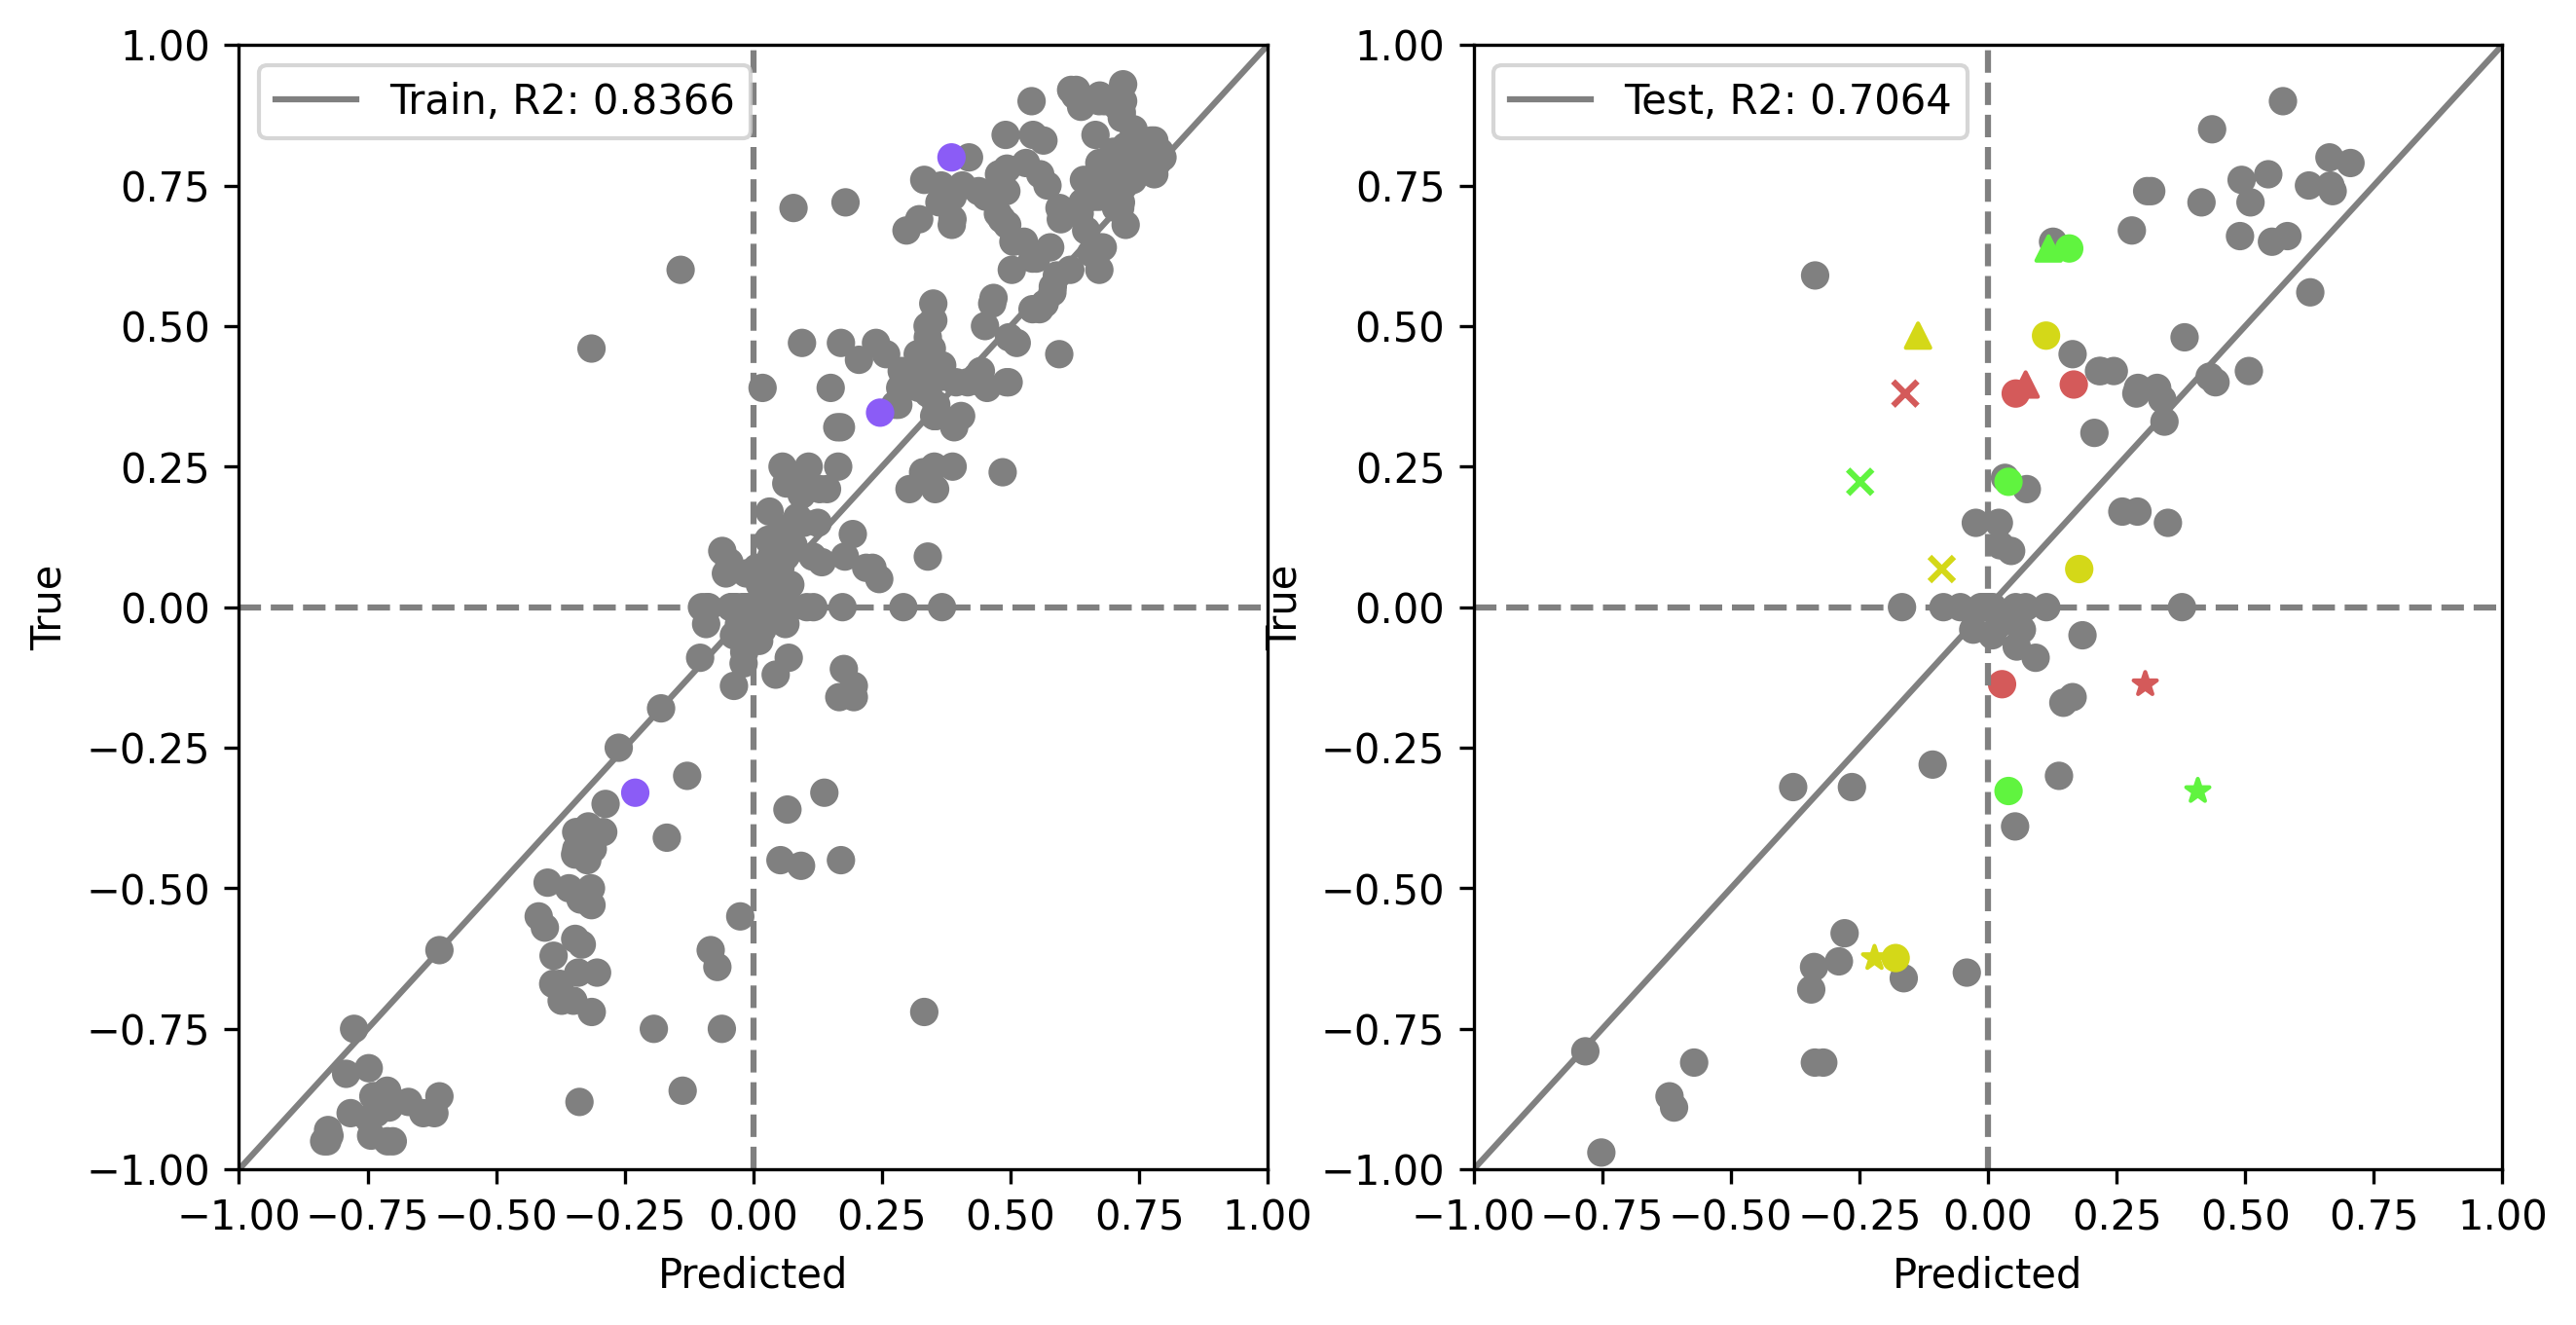

In [43]:
color_s = ["gray", "#8b5cf6", "#d4d818", "#60f43f", "#d45a5a"]
fig, ax = plt.subplots(1, 2, figsize = (10, 5), dpi = 300)
ax[0].scatter(train_pred, y_train_new, c = [color_s[i] for i in class_train_new])
ax[0].plot([-1, 1], [-1, 1], label = "Train, R2: {:.4f}".format(r2_train), c = "gray")
ax[0].plot([0, 0], [-1, 1], c = "gray", linestyle = "--")
ax[0].plot([-1, 1], [0, 0], c = "gray", linestyle = "--")
ax[0].set_xlim([-1, 1])
ax[0].set_ylim([-1, 1])
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")
    
ax[1].scatter(test_pred, y_test_new, c = [color_s[i] for i in class_test_new])
ax[1].plot([-1, 1], [-1, 1], label = "Test, R2: {:.4f}".format(r2_test), c = "gray")
ax[1].plot([0, 0], [-1, 1], c = "gray", linestyle = "--")
ax[1].plot([-1, 1], [0, 0], c = "gray", linestyle = "--")
ax[1].set_xlim([-1, 1])
ax[1].set_ylim([-1, 1])
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")

ax[1].scatter(cat_71_pred_press_20, cat_71_exp_press_20, c = ["#d4d818", "#60f43f", "#d45a5a"], marker = "x")
ax[1].scatter(cat_72_pred_press_20, cat_72_exp_press_20, c = ["#d4d818", "#60f43f", "#d45a5a"], marker = "*")
ax[1].scatter(cat_73_pred_press_20, cat_73_exp_press_20, c = ["#d4d818", "#60f43f", "#d45a5a"], marker = "^")
ax[0].legend()
ax[1].legend()


In [ ]:
from joblib import dump, load
# 需保存模型
dump(model, "xgb_model_seed_1_split_0-2.pkl")